In [1]:
#Import block: 
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import pandas as pd

from iminuit import Minuit, cost

from scipy import stats, interpolate
from scipy.interpolate import interp1d, CubicSpline
from scipy.integrate import quad

## Problem 2: Exam in Advanced Methods in Applied Statistics
Author: Aske Roelshøj

KU-ID: KVF851

Date(s): Thurs. March 26 to Fri. March 27, 2026

## 2a

In [ ]:
#load data: 
data = pd.read_csv('Data/Exam_2026_Problem2.txt', delimiter = ' ', skiprows=1)
azimuth, zenith = data[data.columns[0]], data[data.columns[1]]
azimuth = np.array(azimuth) #rads
zenith = np.array(zenith) #rads

Note: Some of the code for this part was inspired by Chamilla Terp (https://github.com/ChamillaTerp/AMAS2025/tree/main/Exam%202025) and Kimi Kreilgaard (https://github.com/KimiKreil/Advanced-Methods-in-Applied-Statistics).

In [3]:
#Sample isotropic data: 

def isotropic_sampling(Npoints, seed):
    np.random.seed(seed)
    sampled_azimuth = np.random.uniform(0, 2 * np.pi, Npoints)
    sampled_cos_zenith = np.random.uniform(-1, 1, Npoints)
    sampled_zenith = np.arccos(sampled_cos_zenith)
    return sampled_azimuth, sampled_zenith

Npoints = len(azimuth)
sampled_azimuth, sampled_zenith = isotropic_sampling(Npoints, 1)

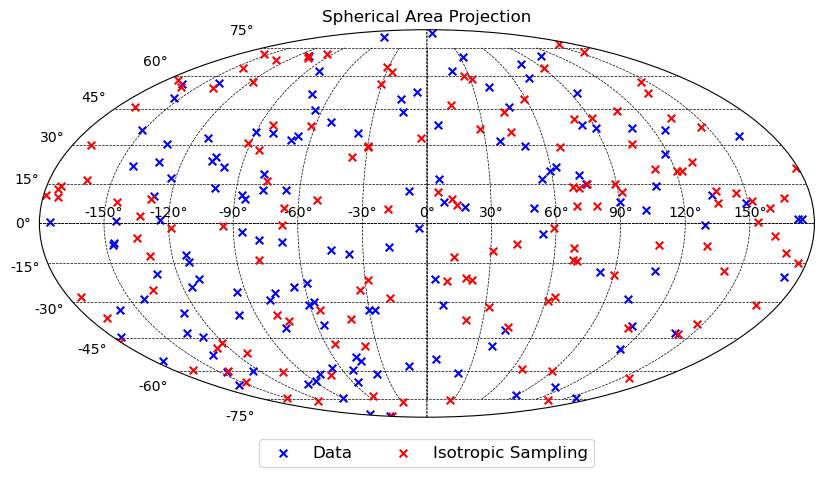

In [5]:
#Plot the data: 
def projection(azimuth, zenith, ax, color, label):
    ax.grid(color = 'black', linestyle = '--', linewidth = 0.5)

    # Meridian and equator
    meridian = np.stack([np.zeros(100), np.linspace(0, np.pi, 100) - np.pi / 2], axis = 1)
    equator = np.stack([np.linspace(0, 2 * np.pi, 100) - np.pi, np.zeros(100)], axis = 1)

    ax.plot(meridian[:,0], meridian[:,1], color = 'black', linestyle = '--', linewidth = 0.5)
    ax.plot(equator[:,0], equator[:,1], color = 'black', linestyle = '--', linewidth = 0.5)

    # Plotting the data
    ax.scatter(azimuth - np.pi, -zenith + np.pi / 2, marker = 'x', color = color, s = 30, zorder = 2, label = label)
# Plotting the data 
fig, ax = plt.subplots(figsize = (10, 10), subplot_kw = {'projection': 'mollweide'})

projection(azimuth, zenith, ax, color = 'b', label = 'Data')
projection(sampled_azimuth, sampled_zenith, ax, color = 'r', label= 'Isotropic Sampling')
ax.set_title('Spherical Area Projection')
ax.legend(loc = 'lower center', bbox_to_anchor = (0.5, -0.15), ncols = 2, fontsize = 12);

In [4]:
def to_cartesian(r, azimuth, zenith):
    x = r * np.cos(azimuth) * np.sin(zenith)
    y = r * np.sin(azimuth) * np.sin(zenith)
    z = r * np.cos(zenith)
    return np.array([x, y, z])

In [5]:
# Two-point correlation function
def two_point_corr_func(azimuth, zenith, bins):
    Npoints = len(azimuth)
    r = 1 #unit vec.            
    data_cartesian = to_cartesian(r, azimuth, zenith)                                           
                                         
    # Defining a range of cos phi's (x-axis)
    cos_phi_bins = np.linspace(-1, 1, bins)

    # Making a list to store angular distance pairs, i.e. all cos(phi_ij)
    cos_phi_ij_list = []

    for i in range(0, Npoints):
        for j in range(0, i):
            cos_phi_ij = np.dot(data_cartesian[:, i], data_cartesian[:, j]) / (np.linalg.norm(data_cartesian[:, i]) * np.linalg.norm(data_cartesian[:, j])) #cosine of the angle between two vectors
            cos_phi_ij_list.append(cos_phi_ij)

    C_values = []

    for i in range(bins):
        heaviside = np.heaviside(cos_phi_ij_list - cos_phi_bins[i], 0)                            
        two_point = (2 / (Npoints * (Npoints - 1))) * np.sum(heaviside)           # Two-point auto-correlation function 
        C_values.append(two_point)

    # Calculating the isotropic prediction 
    prediction_iso = (1/2) * (1 - cos_phi_bins)                                                       # Cumulative two-point auto-correlation function for perfect isotropic data

    return cos_phi_bins, C_values, prediction_iso

In [6]:
x, C, prediction_iso = two_point_corr_func(azimuth, zenith, 100)
x_sim, C_sim, prediction_iso_sim = two_point_corr_func(sampled_azimuth, sampled_zenith, 100)

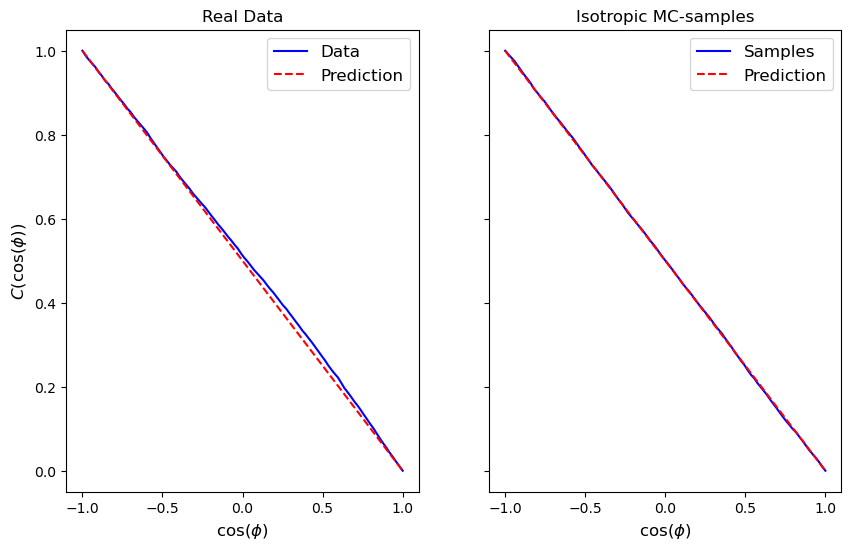

In [10]:
#Plot C vs cos(phi):
fig, axes = plt.subplots(1, 2, figsize = (10, 6), sharey=True)

axes[0].plot(x, C, label = 'Data',  color = 'b')
axes[0].plot(x, prediction_iso, label = 'Prediction', color = 'r', linestyle = '--')
axes[0].set_xlabel(r'$\cos(\phi)$', fontsize = 12)  
axes[0].set_ylabel(r'$C(\cos(\phi))$', fontsize = 12)
axes[0].set_title('Real Data')

axes[1].plot(x_sim, C_sim, label = 'Samples', color = 'b')
axes[1].plot(x_sim, prediction_iso_sim, label = 'Prediction', color = 'r', linestyle = '--')
axes[1].set_xlabel(r'$\cos(\phi)$', fontsize = 12)
axes[1].set_title('Isotropic MC-samples')
axes[0].legend(loc = 'upper right', fontsize = 12)
axes[1].legend(loc = 'upper right', fontsize = 12);

In [11]:
# Using a KS-test to compare the two-point correlation functions 
# Real data 
ks_stat_real = np.max(np.abs(C - prediction_iso))
print(f'KS-statistic for real data: {ks_stat_real:.4f}')
# Simulated data
ks_stat_sim = np.max(np.abs(C_sim - prediction_iso_sim))
print(f'KS-statistic for simulated data: {ks_stat_sim:.4f}')

KS-statistic for real data: 0.0221
KS-statistic for simulated data: 0.0047


In [12]:
#Lets simulate KS stat distribution for isotropic data.

Nexp = 2_500

ks_Nexp = []
for i in range(Nexp):
    sampled_azimuth, sampled_zenith = isotropic_sampling(Npoints, i+1)
    _, C_sim, prediction_iso_sim = two_point_corr_func(sampled_azimuth, sampled_zenith, 100)
    ks_stat_sim = np.max(np.abs(C_sim - prediction_iso_sim))
    ks_Nexp.append(ks_stat_sim)
ks_Nexp = np.array(ks_Nexp)

In [13]:
#Determine the p-value: 
p_value = np.sum(ks_Nexp >= ks_stat_real) / Nexp
print(f'p-value: {p_value:.4f}')

p-value: 0.0028


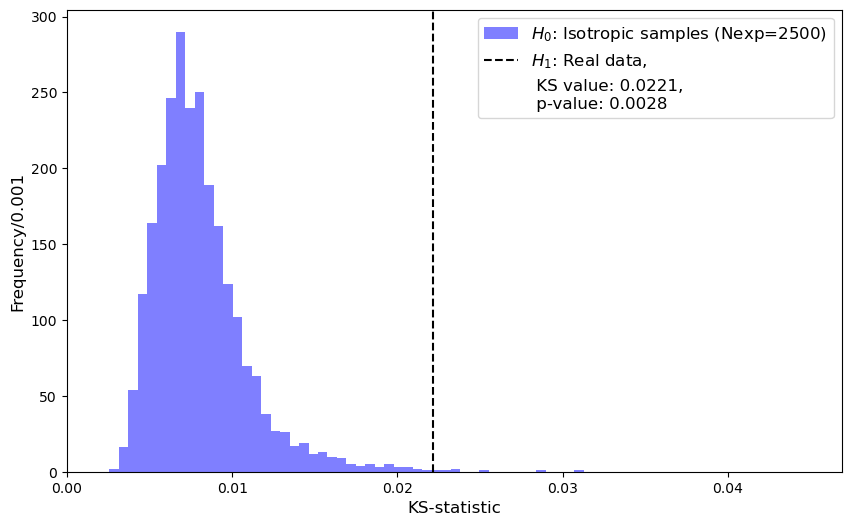

In [14]:
#Plot the data: 
fig, ax = plt.subplots(figsize = (10, 6))
ax.hist(ks_Nexp, bins = 50, alpha = 0.5, color = 'b', label = f'$H_0$: Isotropic samples (Nexp={Nexp})')
ax.axvline(ks_stat_real, color = 'k', linestyle = '--', label = f'$H_1$: Real data,')
ax.plot([], [], alpha = 0, label = f' KS value: {ks_stat_real:.4f}, \n p-value: {p_value:.4f}')
ax.set_xlabel('KS-statistic', fontsize = 12)
ax.set_ylabel(f'Frequency/{((np.max(ks_Nexp)-np.min(ks_Nexp))/50):.3f}', fontsize = 12)
ax.set_xlim(0, np.max(ks_Nexp)*1.5)
ax.legend(loc = 'upper right', fontsize = 12);

## 2b

In [15]:
#Lets modify our sampling function for 2b: 
def isotropic_sampling_A(Npoints, seed):
    np.random.seed(seed)

    Nlimited = np.floor(0.2*Npoints)

    azimuth_limits = np.array([0.225, 0.725])*np.pi
    coszenith_limits = np.array([-1, 0])

    # Sample the limited part of the data
    sampled_azimuth_limited = np.random.uniform(azimuth_limits[0], azimuth_limits[1], int(Nlimited))
    sampled_cos_zenith_limited = np.random.uniform(coszenith_limits[0], coszenith_limits[1], int(Nlimited))
    sampled_zenith_limited = np.arccos(sampled_cos_zenith_limited)

    Nunlimited = Npoints - int(Nlimited)
    # Sample the unlimited part of the data
    sampled_azimuth = np.random.uniform(0, 2 * np.pi, Nunlimited)
    sampled_cos_zenith = np.random.uniform(-1, 1, Nunlimited)
    sampled_zenith = np.arccos(sampled_cos_zenith)

    azimuth = np.concatenate([sampled_azimuth_limited, sampled_azimuth])
    zenith = np.concatenate([sampled_zenith_limited, sampled_zenith])

    return azimuth, zenith

def isotropic_sampling_B(Npoints, seed):
    np.random.seed(seed)

    Nlimited = np.floor(0.15*Npoints)

    azimuth_limits = np.array([0, 1])*np.pi
    coszenith_limits = np.array([-1, 0])

    # Sample the limited part of the data
    sampled_azimuth_limited = np.random.uniform(azimuth_limits[0], azimuth_limits[1], int(Nlimited))
    sampled_cos_zenith_limited = np.random.uniform(coszenith_limits[0], coszenith_limits[1], int(Nlimited))
    sampled_zenith_limited = np.arccos(sampled_cos_zenith_limited)

    Nunlimited = Npoints - int(Nlimited)
    # Sample the unlimited part of the data
    sampled_azimuth = np.random.uniform(0, 2 * np.pi, Nunlimited)
    sampled_cos_zenith = np.random.uniform(-1, 1, Nunlimited)
    sampled_zenith = np.arccos(sampled_cos_zenith)

    azimuth = np.concatenate([sampled_azimuth_limited, sampled_azimuth])
    zenith = np.concatenate([sampled_zenith_limited, sampled_zenith])

    return azimuth, zenith


In [16]:
ks_NexpA = []
for i in range(int(Nexp)):
    azimuthA, zenithA = isotropic_sampling_A(Npoints, i+1)
    _, C_simA, prediction_iso_simA = two_point_corr_func(azimuthA, zenithA, 100)
    ks_stat_simA = np.max(np.abs(C_simA - prediction_iso_simA))
    ks_NexpA.append(ks_stat_simA)
ks_NexpA = np.array(ks_NexpA)

ks_NexpB = []
for i in range(int(Nexp)):
    azimuthB, zenithB = isotropic_sampling_B(Npoints, i+1)
    _, C_simB, prediction_iso_simB = two_point_corr_func(azimuthB, zenithB, 100)
    ks_stat_simB = np.max(np.abs(C_simB - prediction_iso_simB))
    ks_NexpB.append(ks_stat_simB)
ks_NexpB = np.array(ks_NexpB)

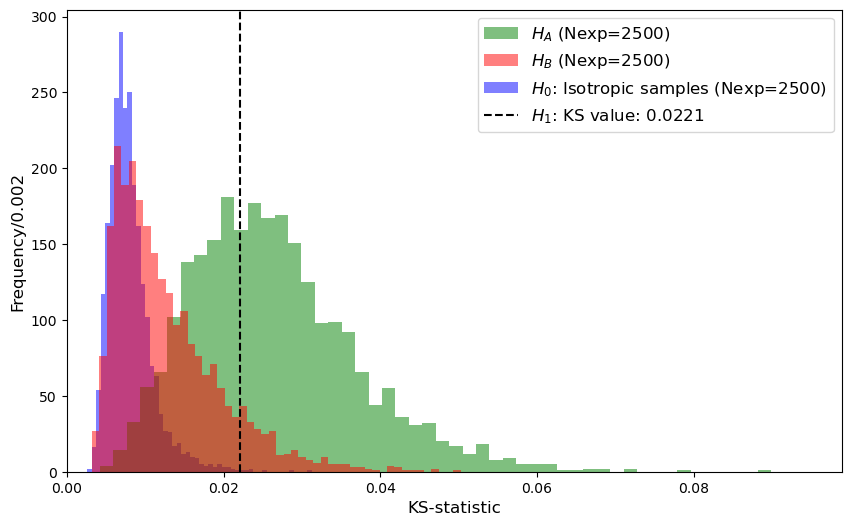

In [17]:
#Plot:

fig, ax = plt.subplots(figsize = (10, 6))
ax.hist(ks_NexpA, bins = 50, alpha = 0.5, color = 'g', label = f'$H_A$ (Nexp={Nexp})')
ax.hist(ks_NexpB, bins = 50, alpha = 0.5, color = 'r', label = f'$H_B$ (Nexp={Nexp})')
ax.hist(ks_Nexp, bins = 50, alpha = 0.5, color = 'b', label = f'$H_0$: Isotropic samples (Nexp={Nexp})', zorder =0)
ax.axvline(ks_stat_real, color = 'k', linestyle = '--', label = f'$H_1$: KS value: {ks_stat_real:.4f}')
ax.set_xlabel('KS-statistic', fontsize = 12)
ax.set_ylabel(f'Frequency/{((np.max(ks_NexpA)-np.min(ks_NexpA))/50):.3f}', fontsize = 12)
ax.set_xlim(0, np.max(ks_NexpA)*1.1)
ax.legend(loc = 'upper right', fontsize = 12);

In [19]:
#find the p-values and make a DF: 
p_valueA1 = np.sum(ks_NexpA >= ks_stat_real) / len(ks_NexpA)
p_valueB1 = np.sum(ks_NexpB >= ks_stat_real) / len(ks_NexpB)

results_df = pd.DataFrame({
    'Hypothesis': ['H_A', 'H_B'],
    'p-value vs H1': [p_valueA1, p_valueB1],
})

#Print to latex::
print(results_df.to_latex(index=False, float_format="%.4f"))


\begin{tabular}{lr}
\toprule
Hypothesis & p-value vs H1 \\
\midrule
H_A & 0.6176 \\
H_B & 0.1040 \\
\bottomrule
\end{tabular}

